In [ ]:
import os, glob, numpy as np, pandas as pd
from scipy.stats import ttest_ind

NPZ_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds"
KEY = 'concept_mean' #"concept_attn_weighted"  # or "concept_mean"
EPS = 1e-6

files = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))
Y, S = [], []
for f in files:
    d = np.load(f, allow_pickle=True)
    Y.append(int(d["y_true"]))
    S.append(np.asarray(d[KEY], dtype=float))
Y = np.asarray(Y); S = np.vstack(S)   # [n_slides, n_concepts]

fa, pt = S[Y==0], S[Y==1]
mean_fa, mean_pt = fa.mean(0), pt.mean(0)
log2fc = np.log2((mean_pt + EPS) / (mean_fa + EPS))
pvals = np.array([ttest_ind(pt[:,i], fa[:,i], equal_var=False, nan_policy="omit").pvalue for i in range(S.shape[1])])
df = pd.DataFrame({"concept_idx": np.arange(S.shape[1]), "mean_FA": mean_fa, "mean_PT": mean_pt,
                   "log2FC_PT_vs_FA": log2fc, "p": pvals, "neglog10p": -np.log10(np.maximum(pvals, 1e-300))})
df.to_csv("concept_mean_volcano_table.csv", index=False)
print(df.sort_values("neglog10p", ascending=False).head(50))

In [1]:
import numpy as np
import glob
import os

NPZ_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds"

files = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))

S = []
Y = []
slide_ids = []

for f in files:
    d = np.load(f, allow_pickle=True)

    S.append(d["concept_attn_weighted"])   # shape (50,)
    Y.append(int(d["y_true"]))
    slide_ids.append(str(d["slide_id"]))

S = np.vstack(S)      # shape → (n_slides, 50)
Y = np.array(Y)       # shape → (n_slides,)
slide_ids = np.array(slide_ids)

print("Concept matrix shape:", S.shape)
print("Labels shape:", Y.shape)

Concept matrix shape: (240, 50)
Labels shape: (240,)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_3932\4041289052.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y.append(int(d["y_true"]))


In [13]:
import pandas as pd

df = pd.DataFrame(S, columns=[f"concept_{i}" for i in range(S.shape[1])])
df["label"] = Y
df["slide_id"] = slide_ids

df.to_csv(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\slide_concept\slide_concept_matrix.csv", index=False)

In [14]:
import numpy as np
from scipy.stats import ttest_ind

fa = S[Y == 0]
pt = S[Y == 1]

mean_FA = fa.mean(axis=0)
mean_PT = pt.mean(axis=0)

pvals = np.array([
    ttest_ind(pt[:,c], fa[:,c], equal_var=False, nan_policy="omit").pvalue
    for c in range(S.shape[1])
])

neglog10p = -np.log10(np.maximum(pvals, 1e-300))

In [8]:
eps = 1e-3
min_val = min(mean_FA.min(), mean_PT.min())
shift = (-min_val + eps) if min_val <= 0 else 0.0

log2fc = np.log2((mean_PT + shift + eps) / (mean_FA + shift + eps))

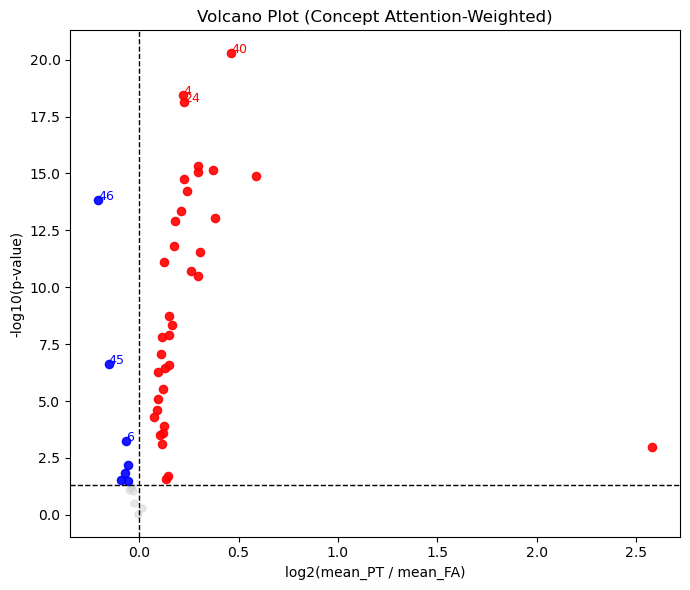

In [15]:
import matplotlib.pyplot as plt

p_thresh = 0.05
sig_line = -np.log10(p_thresh)
is_sig = neglog10p >= sig_line

plt.figure(figsize=(7,6))
idx = np.arange(S.shape[1])
top_pt = idx[(is_sig) & (log2fc > 0)]
top_fa = idx[(is_sig) & (log2fc < 0)]

top_pt = top_pt[np.argsort(neglog10p[top_pt])[::-1]][:3]
top_fa = top_fa[np.argsort(neglog10p[top_fa])[::-1]][:3]

for c in top_pt:
    plt.text(log2fc[c], neglog10p[c], str(c), color="red", fontsize=9)

for c in top_fa:
    plt.text(log2fc[c], neglog10p[c], str(c), color="blue", fontsize=9)
# grey = not significant
plt.scatter(log2fc[~is_sig], neglog10p[~is_sig],
            s=25, alpha=0.5, color="lightgrey")

# significant, PT-enriched (right)
plt.scatter(log2fc[is_sig & (log2fc > 0)], neglog10p[is_sig & (log2fc > 0)],
            s=35, alpha=0.9, color="red")

# significant, FA-enriched (left)
plt.scatter(log2fc[is_sig & (log2fc < 0)], neglog10p[is_sig & (log2fc < 0)],
            s=35, alpha=0.9, color="blue")

plt.axhline(sig_line, linestyle="--", color="black", linewidth=1)
plt.axvline(0, linestyle="--", color="black", linewidth=1)

plt.xlabel("log2(mean_PT / mean_FA)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Concept Attention-Weighted)")
plt.tight_layout()
plt.show()

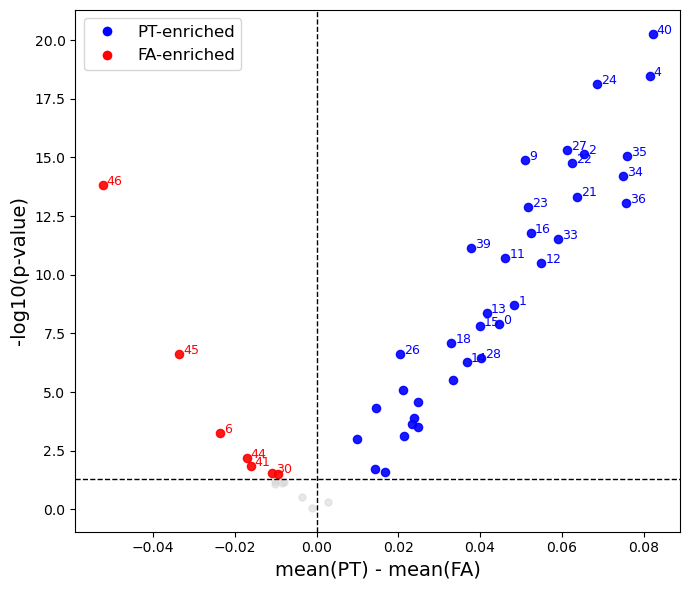

In [38]:
import numpy as np
import matplotlib.pyplot as plt

p_thresh = 0.05
sig_line = -np.log10(p_thresh)
is_sig = neglog10p >= sig_line

# signed effect size (recommended for x-axis)
diff = mean_PT - mean_FA

plt.figure(figsize=(7,6))
idx = np.arange(len(diff))

top_pt = idx[(is_sig) & (diff > 0)]
top_fa = idx[(is_sig) & (diff < 0)]

top_pt = top_pt[np.argsort(neglog10p[top_pt])[::-1]][:25]
top_fa = top_fa[np.argsort(neglog10p[top_fa])[::-1]][:6]

x_offset = 0.001
y_offset = 0.002

for c in top_pt:
    plt.text(diff[c] + x_offset, neglog10p[c] + y_offset, str(c), color="blue", fontsize=9)
for c in top_fa:
    plt.text(diff[c] + x_offset, neglog10p[c] + y_offset, str(c), color="red", fontsize=9)

# grey = not significant
plt.scatter(diff[~is_sig], neglog10p[~is_sig],
            s=25, alpha=0.5, color="lightgrey")

# significant, PT-enriched (right)
plt.scatter(diff[is_sig & (diff > 0)], neglog10p[is_sig & (diff > 0)],
            s=35, alpha=0.9, color="blue")

# significant, FA-enriched (left)
plt.scatter(diff[is_sig & (diff < 0)], neglog10p[is_sig & (diff < 0)],
            s=35, alpha=0.9, color="red")

plt.axhline(sig_line, linestyle="--", color="black", linewidth=1)
plt.axvline(0, linestyle="--", color="black", linewidth=1)

from matplotlib.lines import Line2D

legend_elems = [
    # Line2D([0],[0], marker='o', color='w', label='Concept Mean', markerfacecolor='grey', markersize=8, alpha=0.4),
    Line2D([0],[0], marker='o', color='w', label='PT-enriched', markerfacecolor='blue', markersize=8),
    Line2D([0],[0], marker='o', color='w', label='FA-enriched', markerfacecolor='red', markersize=8),
]

# increse scale number size

plt.legend(handles=legend_elems, loc="upper left", prop={'size': 12})
plt.xlabel("mean(PT) - mean(FA)", size=14)
plt.ylabel("-log10(p-value)", size=14)
# plt.title("Volcano Plot (Concept Attention-Weighted)")
plt.tight_layout()
plt.show()

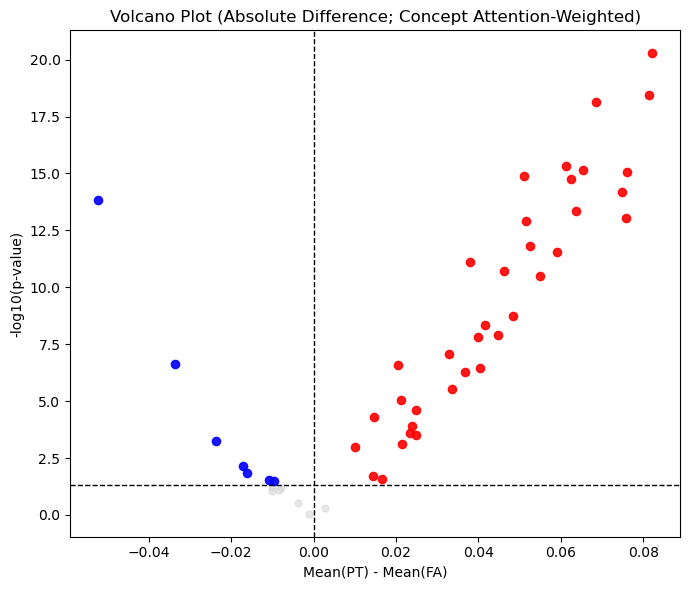

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load
# S = np.load("slide_concept_matrix.npy")   # (n_slides, 50)
# Y = np.load("slide_labels.npy")           # (n_slides,)

# Split by true label
fa = S[Y == 0]
pt = S[Y == 1]

# Per-concept means
mean_FA = fa.mean(axis=0)
mean_PT = pt.mean(axis=0)

# X-axis: absolute difference (PT - FA)
diff = mean_PT - mean_FA

# Per-concept p-values (Welch t-test)
pvals = np.array([
    ttest_ind(pt[:,c], fa[:,c], equal_var=False, nan_policy="omit").pvalue
    for c in range(S.shape[1])
])

# Y-axis: -log10(p)
neglog10p = -np.log10(np.maximum(pvals, 1e-300))

# Plot with p-value threshold only
p_thresh = 0.05
sig_line = -np.log10(p_thresh)
is_sig = neglog10p >= sig_line

plt.figure(figsize=(7,6))

# Not significant
plt.scatter(diff[~is_sig], neglog10p[~is_sig],
            s=25, alpha=0.5, color="lightgrey")

# Significant PT-enriched (diff > 0)
plt.scatter(diff[is_sig & (diff > 0)], neglog10p[is_sig & (diff > 0)],
            s=35, alpha=0.9, color="red")

# Significant FA-enriched (diff < 0)
plt.scatter(diff[is_sig & (diff < 0)], neglog10p[is_sig & (diff < 0)],
            s=35, alpha=0.9, color="blue")

plt.axhline(sig_line, linestyle="--", color="black", linewidth=1)
plt.axvline(0, linestyle="--", color="black", linewidth=1)

plt.xlabel("Mean(PT) - Mean(FA)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Absolute Difference; Concept Attention-Weighted)")
plt.tight_layout()
plt.show()